In [25]:
import numpy as np
import scanpy as sc
from matplotlib import pyplot as plt

# Load the original dataset and the top5k dataset

In [26]:
og_data_path = "../data/sct_matrix_transposed.npz"
top5k_data_path = "../data/sct_top5k.npz"
og_data = np.load(og_data_path)
top5k_data = np.load(top5k_data_path)

In [11]:
og_keys = og_data.files
top5k_keys = top5k_data.files
og_exp_matrix = og_data[og_keys[0]]
print("Original data keys:", og_keys)
top5k_exp_matrix = top5k_data[top5k_keys[0]]
print("Top 5k data keys:", top5k_keys)
print("Original data shape:", og_exp_matrix.shape)
print("Top 5k data shape:", top5k_exp_matrix.shape)

Original data keys: ['arr_0']
Top 5k data keys: ['data', 'genes', 'cells']
Original data shape: (51099, 16647)
Top 5k data shape: (5000, 50929)


In [27]:
# Convert to AnnData objects for Scanpyz
og_hvg = sc.AnnData(og_exp_matrix)
# Identify highly variable genes in the original dataszet
sc.pp.highly_variable_genes(og_hvg, n_top_genes=5000, subset=True, flavor='seurat_v3')
# Print the shape of the filtered original dataset
print("Filtered original data shape (top 5k genes):", og_adata.X.shape)

c:\Users\rdbra\Documents\honoursProject\code_base\Hon_proj_RDB\GRN_work\.venv_grn\Lib\site-packages\legacy_api_wrap\__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


Filtered original data shape (top 5k genes): (51099, 5000)


Non-zero entries in original data: 26796821
Non-zero entries in top 5k data: 43541057
Density of original data: 0.10488197812090257
Density of top 5k data: 0.17098728425847748


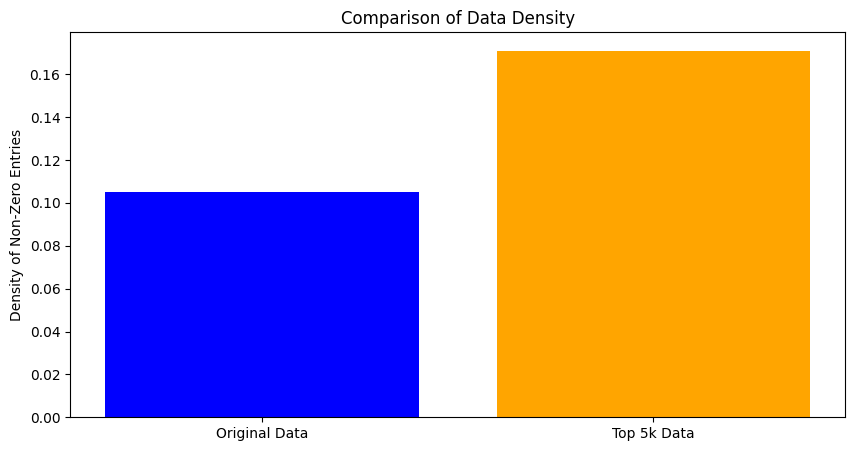

In [ ]:
og_non_zero = np.count_nonzero(og_hvg.X)
top5k_non_zero = np.count_nonzero(top5k_exp_matrix)
print("Non-zero entries in original data:", og_non_zero)
print("Non-zero entries in top 5k data:", top5k_non_zero)
og_density = og_non_zero / og_adata.X.size
top5k_density = top5k_non_zero / top5k_adata.X.size
print("Density of original data:", og_density)
print("Density of top 5k data:", top5k_density)
plt.figure(figsize=(10, 5))
plt.bar(['Original Data', 'Top 5k Data'], [og_density, top5k_density], color=['blue', 'orange'])
plt.ylabel('Density of Non-Zero Entries')   
plt.title('Comparison of Data Density')
plt.show()


In [28]:
og_high_exp = sc.AnnData(og_exp_matrix)
og_high_exp.var['mean_expression'] = np.ravel(og_high_exp.X.mean(axis=0))
og_top5k_exp = og_high_exp.var.nlargest(5000, 'mean_expression').index
og_top5k_exp_subset = og_high_exp[:, og_top5k_exp].copy()
print("Shape of original data subsetted to top 5k highly expressed genes:", og_top5k_exp_subset.X.shape) 

Shape of original data subsetted to top 5k highly expressed genes: (51099, 5000)


Non-zero entries in original data subsetted to top 5k highly expressed genes: 65048695
Percentage of original data subsetted to top 5k highly expressed genes: 25.46%


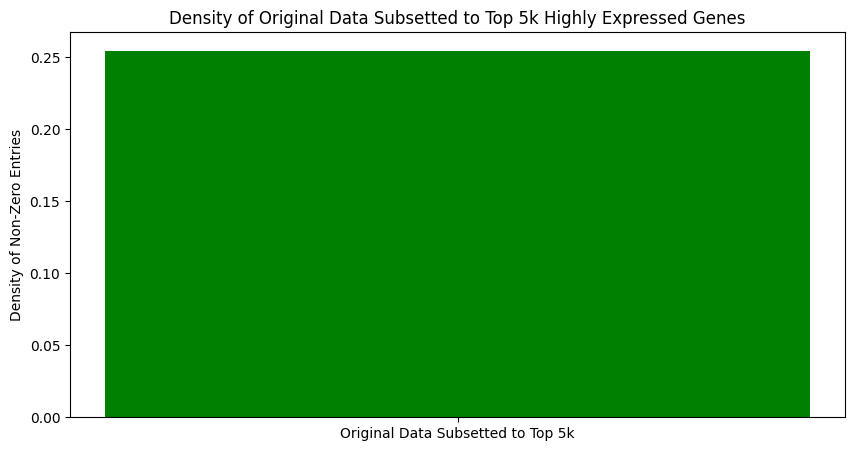

In [31]:
# Calculate the percentage of non-zero enties in the subsetted original data
og_top5k_non_zero = np.count_nonzero(og_top5k_exp_subset.X)
og_top5k_density = og_top5k_non_zero / og_top5k_exp_subset.X.size
print("Non-zero entries in original data subsetted to top 5k highly expressed genes:", og_top5k_non_zero)
print("Percentage of original data subsetted to top 5k highly expressed genes:", f"{og_top5k_density * 100:.2f}%")
plt.figure(figsize=(10, 5))
plt.bar(['Original Data Subsetted to Top 5k'], [og_top5k_density], color=['green'])
plt.ylabel('Density of Non-Zero Entries')   
plt.title('Density of Original Data Subsetted to Top 5k Highly Expressed Genes')
plt.show()

In [ ]:
sct_top5k_copy_path = "../data/sct_top5k_copy.npz"
sct_top5k_copy = np.load(sct_top5k_copy_path)
sct_top5k_copy_keys = sct_top5k_copy.files
sct_top5k_copy_matrix = sct_top5k_copy[sct_top5k_copy_keys[0]]
print("Top 5k data shape from copy file:", sct_top5k_copy_matrix.shape)
#Calculate the density of non-zero entries in the copied top 5k data
sct_top5k_copy_non_zero = np.count_nonzero(sct_top5k_copy_matrix)
sct_top5k_copy_density = sct_top5k_copy_non_zero / sct_top5k_copy_matrix.size
print("Density of copied top 5k data:", f"{sct_top5k_copy_density * 100:.2f}%")

Top 5k data shape from copy file: (5000, 50929)
Density of copied top 5k data: 17.10%
